In [1]:
import numpy as np
import matplotlib.pyplot as plt
from control import *
import sys
sys.path.append('../..')
from simulation.model.motor_params import *

In [3]:
# Transfer function
num = [Kt]
den = [J*L, J*R + B*L, B*R + Ke*Kt]
motor_tf = tf(num, den)

# PID 
Kp = 10.0
Ki = 5.0
Kd = 0.1
pid_tf = tf([Kd, Kp, Ki], [1, 0])

# Closed loop
open_loop = pid_tf * motor_tf
closed_loop = feedback(open_loop, 1)

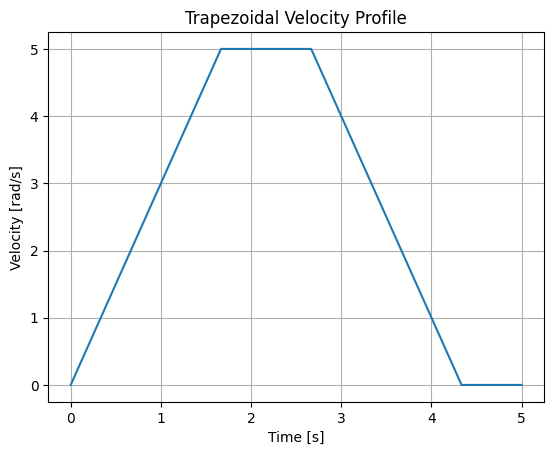

In [10]:
def trapezoidal_profile(t, v_max, a_max, t_start=0):
    """
    Generates trapezoidal velocity profile
    v_max  - maximum velocity [rad/s]
    a_max  - maximum acceleration [rad/s^2]
    """

    t_acc = v_max / a_max          # acceleration time (from v = a * dt)
    t_flat = 1.0                   # constant velocity time [s]
    t_total = 2 * t_acc + t_flat   # total time
    profile = np.zeros_like(t)

    for i, ti in enumerate(t - t_start):
        if ti < 0:
            profile[i] = 0
        elif ti < t_acc:
            profile[i] = a_max * ti          # acceleration
        elif ti < t_acc + t_flat:
            profile[i] = v_max               # constant velocity
        else:
            profile[i] = v_max - a_max * (ti - t_acc - t_flat)  # deceleration
        profile[i] = max(0, profile[i])
    return profile

# Generate profile
t = np.linspace(0, 5, 1000)
v_max = 5.0    # rad/s
a_max = 3.0    # rad/s^2

setpoint = trapezoidal_profile(t, v_max, a_max)

plt.plot(t, setpoint)
plt.xlabel('Time [s]')
plt.ylabel('Velocity [rad/s]')
plt.title('Trapezoidal Velocity Profile')
plt.grid(True)
plt.show()

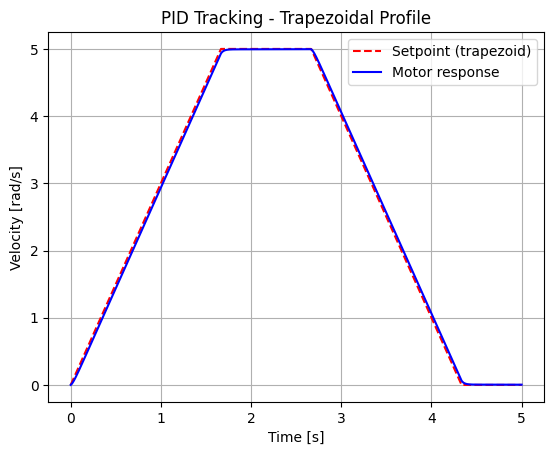

In [12]:
# Simulate PID tracking of trapezoidal profile
from scipy.integrate import odeint

def system(state, t_val, setpoint_func):
    # state = velocity
    sp = setpoint_func
    error = sp - state[0]
    # simplified - closed loop response
    return error

t_sim = np.linspace(0, 5, 1000)
t_out, y_out = forced_response(closed_loop, T=t_sim, U=setpoint) 

plt.plot(t_sim, setpoint, 'r--', label='Setpoint (trapezoid)')
plt.plot(t_sim, y_out, 'b', label='Motor response')
plt.xlabel('Time [s]')
plt.ylabel('Velocity [rad/s]')
plt.title('PID Tracking - Trapezoidal Profile')
plt.legend()
plt.grid(True)
plt.show()


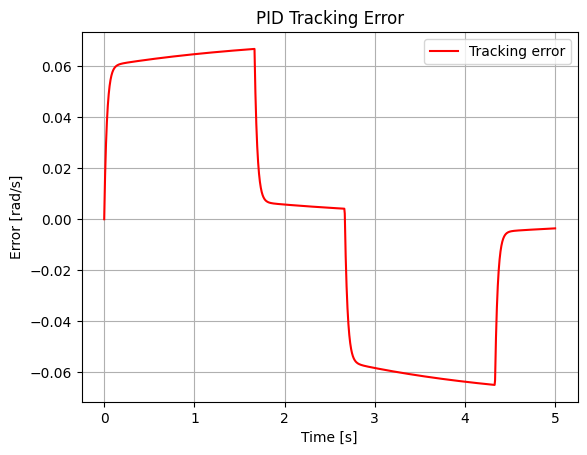

In [13]:
# Tracking error
error = setpoint - y_out

plt.plot(t_sim, error, 'r', label='Tracking error')
plt.xlabel('Time [s]')
plt.ylabel('Error [rad/s]')
plt.title('PID Tracking Error')
plt.legend()
plt.grid(True)
plt.show()